In [9]:
import numpy as np
import pandas as pd

## Reading the Training Dataset

In [15]:
X = pd.read_csv('./data/train.csv')
X.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
X.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [17]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
y = X['Survived']
X = X[features]

In [18]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    str    
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    str    
dtypes: float64(2), int64(3), str(2)
memory usage: 48.9 KB


## Splitting Dataset into Training and Development/Test dataset

In [19]:
## Divide the dataset into test-train

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

## Performing basic transformations - OHE, Imputation

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Sex', 'Embarked']),
    ('impute', SimpleImputer(strategy='median'), ['Age'])
], remainder='passthrough')

X_train_trf = ct.fit_transform(X_train)
X_test_trf = ct.transform(X_test)

In [25]:
X_train_trf_df = pd.DataFrame(X_train_trf, columns=ct.get_feature_names_out())
X_test_trf_df = pd.DataFrame(X_test_trf, columns=ct.get_feature_names_out())

In [26]:
X_test_trf_df.head()

,ohe__Sex_female,ohe__Sex_male,ohe__Embarked_C,ohe__Embarked_Q,ohe__Embarked_S,ohe__Embarked_nan,impute__Age,remainder__Pclass,remainder__SibSp,remainder__Parch,remainder__Fare
0,0.0,1.0,1.0,0.0,0.0,0.0,29.498846,3.0,1.0,1.0,15.2458
1,0.0,1.0,0.0,0.0,1.0,0.0,31.000000,2.0,0.0,0.0,10.5000
2,0.0,1.0,0.0,0.0,1.0,0.0,20.000000,3.0,0.0,0.0,7.9250
3,1.0,0.0,0.0,0.0,1.0,0.0,6.000000,2.0,0.0,1.0,33.0000
4,1.0,0.0,1.0,0.0,0.0,0.0,14.000000,3.0,1.0,0.0,11.2417


In [27]:
X_train_trf_df.head()

,ohe__Sex_female,ohe__Sex_male,ohe__Embarked_C,ohe__Embarked_Q,ohe__Embarked_S,ohe__Embarked_nan,impute__Age,remainder__Pclass,remainder__SibSp,remainder__Parch,remainder__Fare
0,0.0,1.0,0.0,0.0,1.0,0.0,45.5,1.0,0.0,0.0,28.5000
1,0.0,1.0,0.0,0.0,1.0,0.0,23.0,2.0,0.0,0.0,13.0000
2,0.0,1.0,0.0,0.0,1.0,0.0,32.0,3.0,0.0,0.0,7.9250
3,0.0,1.0,0.0,0.0,1.0,0.0,26.0,3.0,1.0,0.0,7.8542
4,1.0,0.0,0.0,0.0,1.0,0.0,6.0,3.0,4.0,2.0,31.2750


In [35]:
## Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_trf_df_scaled = scaler.fit_transform(X_train_trf_df)
X_test_trf_df_scaled = scaler.transform(X_test_trf_df)

In [38]:
X_train_final = pd.DataFrame(X_train_trf_df_scaled, columns=scaler.get_feature_names_out())
X_test_final = pd.DataFrame(X_test_trf_df_scaled, columns=scaler.get_feature_names_out())

In [40]:
X_test_final.head()

,ohe__Sex_female,ohe__Sex_male,ohe__Embarked_C,ohe__Embarked_Q,ohe__Embarked_S,ohe__Embarked_nan,impute__Age,remainder__Pclass,remainder__SibSp,remainder__Parch,remainder__Fare
0,-0.724310,0.724310,2.167026,-0.303355,-1.675556,-0.053074,2.735977e-16,0.813034,0.379923,0.784700,-0.333901
1,-0.724310,0.724310,-0.461462,-0.303355,0.596817,-0.053074,1.156052e-01,-0.400551,-0.470722,-0.479342,-0.425284
2,-0.724310,0.724310,-0.461462,-0.303355,0.596817,-0.053074,-7.315147e-01,0.813034,-0.470722,-0.479342,-0.474867
3,1.380624,-1.380624,-0.461462,-0.303355,0.596817,-0.053074,-1.809667e+00,-0.400551,-0.470722,0.784700,0.007966
4,1.380624,-1.380624,2.167026,-0.303355,-1.675556,-0.053074,-1.193580e+00,0.813034,0.379923,-0.479342,-0.411002


## Building a basic Logistic Regression Model

In [41]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_final, y_train)
y_pred = lr.predict(X_test_final)

In [44]:
# Accuracy on Development/Testing set
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8100558659217877


In [45]:
# Accuracy on training set
print(accuracy_score(y_train, lr.predict(X_train_final)))

0.8019662921348315


## Performing Bias-Variance Diagnostic

In [56]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

class BiasVarianceDiagnostic:
    def __init__(self, model, X_train, X_test, y_train, y_test):
        """
        Parameters:
        -----------
        model : sklearn model, trained model to diagnose
        X_train, X_test, y_train, y_test : arrays, training/test data
        """
        self.model = model
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        # Calculate error (1-accuracy)
        self.train_error = 1 - accuracy_score(y_train, self.model.predict(X_train))
        self.test_error = 1 - accuracy_score(y_test, self.model.predict(X_test))

    def diagnose(self):
        """
        Simple heuristic diagnosis - compare train vs test error
        """
        print("=" * 70)
        print("BIAS vs VARIANCE DIAGNOSIS")
        print("=" * 70)
        
        print(f"\nTraining Error: {self.train_error:.4f}")
        print(f"Test Error:     {self.test_error:.4f}")
        print(f"Difference:     {abs(self.test_error - self.train_error):.4f}")
        
        gap = self.test_error - self.train_error
        
        print("\n" + "─" * 70)
        print("DIAGNOSIS:")
        print("─" * 70)

        if self.train_error > 0.15:
            diagnosis = "HIGH BIAS (Underfitting)"
            print(f"✗ {diagnosis}")
        elif gap > 0.05:
            diagnosis = "HIGH VARIANCE (Overfitting)"
            print(f"✓ {diagnosis}")
        else:
            diagnosis = "GOOD BALANCE"
            print(f"✓ {diagnosis}")
        
        print("\n" + "=" * 70 + "\n")
        return diagnosis
    
    def plot_curve(self):
        train_sizes, train_scores, val_scores = learning_curve(
            self.model, self.X_train, self.y_train,
            train_sizes=np.linspace(0.1, 1.0, 5),
            cv=5,
            scoring='accuracy'
        )
        train_errors = 1-train_scores.mean(axis=1)
        val_errors = 1 - val_scores.mean(axis=1)

        # You want to reach 85% accuracy = 0.15 error
        target_accuracy = 0.85
        target_error = 1 - target_accuracy

        plt.figure(figsize=(10, 6))
        plt.plot(train_sizes, train_errors, 'o-', label='Train Error', linewidth=2)
        plt.plot(train_sizes, val_errors, 's-', label='Val Error', linewidth=2)
        plt.axhline(y=target_error, color='green', linestyle='--', linewidth=2, label=f'Target: {target_error:.3f}')
        plt.xlabel('Training Set Size')
        plt.ylabel('Error Rate')
        plt.title('Learning Curve')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


BIAS vs VARIANCE DIAGNOSIS

Training Error: 0.1980
Test Error:     0.1899
Difference:     0.0081

──────────────────────────────────────────────────────────────────────
DIAGNOSIS:
──────────────────────────────────────────────────────────────────────
✗ HIGH BIAS (Underfitting)




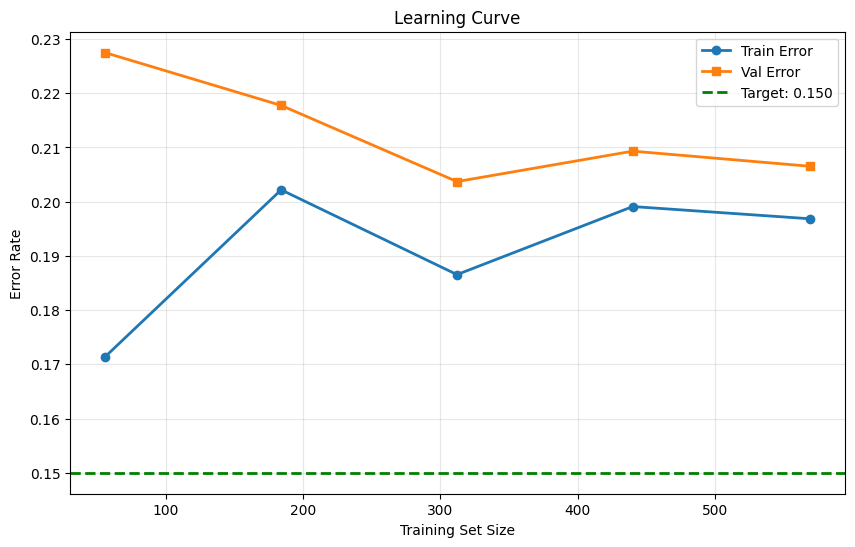

In [57]:
diagnostic = BiasVarianceDiagnostic(model=lr, X_train=X_train_final, X_test=X_test_final, y_train=y_train, y_test=y_test)
diagnostic.diagnose()
diagnostic.plot_curve()